<a href="https://colab.research.google.com/github/Zuhair0000/TensorFlow-ML-DL-Project-Practice/blob/main/tabular_level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
import pandas as pd

In [19]:
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [21]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

In [22]:
X = df.drop(columns=('median_house_value'), axis=1)
y = df['median_house_value']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
X_train.shape, X_test.shape

((16512, 9), (4128, 9))

# Machine Learning

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

num_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income']
cat_cols = ['ocean_proximity']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ocean_proximity'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [38]:
y_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, y_pred)

In [39]:
print(f"Random Forest MAE: {rf_mae:.2f}")

Random Forest MAE: 31628.59


# Deep Learning (TF)

In [25]:
import tensorflow as tf

def df_to_dataset(dataframe, labels, shuffle=True, batch_size=32):
  df = dataframe.copy()

  ds = tf.data.Dataset.from_tensor_slices((dict(df), labels))

  if shuffle:
    ds = ds.shuffle(buffer_size=len(dataframe))


  ds = ds.batch(batch_size)
  ds = ds.prefetch(tf.data.AUTOTUNE)

  return ds

In [26]:
train_ds = df_to_dataset(X_train, y_train)
test_ds = df_to_dataset(X_test, y_test, shuffle=False)

In [27]:
for x, y in train_ds.take(1):
  print(f"Features keys: {list(x.keys())}")

Features keys: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity']


In [28]:
def get_normalization_layer(name, dataset):
  normalizer = tf.keras.layers.Normalization(axis=None)

  features_ds = dataset.map(lambda x, y: x[name])

  normalizer.adapt(features_ds)

  return normalizer

In [29]:
import numpy as np

income_layer = get_normalization_layer('median_income', train_ds)
print(f"Adaped Variance: {income_layer.variance.numpy()}")

Adaped Variance: [[3.6261165]]


In [30]:
def get_category_encoding_layer(name, dataset):

  lookup = tf.keras.layers.StringLookup(output_mode='one_hot')

  features_ds = dataset.map(lambda x, y: x[name])

  lookup.adapt(features_ds)

  return lookup

In [31]:
ocean_layer = get_category_encoding_layer('ocean_proximity', train_ds)
print(f"Learned Vocabulary: {ocean_layer.get_vocabulary()}")

Learned Vocabulary: ['[UNK]', np.str_('<1H OCEAN'), np.str_('INLAND'), np.str_('NEAR OCEAN'), np.str_('NEAR BAY'), np.str_('ISLAND')]


In [32]:
all_inputs = []
encoded_features = []

# 1. Route the 8 Numerical Columns
numerical_cols = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
                  'total_bedrooms', 'population', 'households', 'median_income']

for header in numerical_cols:
  numerical_col = tf.keras.Input(shape=(1, ), name=header)

  normalization_layer = get_normalization_layer(header, train_ds)

  encoded_numerical_col = normalization_layer(numerical_col)

  all_inputs.append(numerical_col)
  encoded_features.append(encoded_numerical_col)

categorical_col = tf.keras.Input(shape=(1, ), name='ocean_proximity', dtype='string')
encoding_layer = get_category_encoding_layer('ocean_proximity', train_ds)
encoded_categorical_col = encoding_layer(categorical_col)

all_inputs.append(categorical_col)
encoded_features.append(encoded_categorical_col)

In [33]:
all_features = tf.keras.layers.concatenate(encoded_features)

In [34]:
x = tf.keras.layers.Dense(128, activation='relu')(all_features)
x = tf.keras.layers.Dense(63, activation='relu')(x)
x = tf.keras.layers.Dense(32, activation='relu')(x)

output = tf.keras.layers.Dense(1)(x)

model = tf.keras.Model(all_inputs, output)

model.compile(optimizer='Adam',
              loss = 'mse',
              metrics=['mae'])

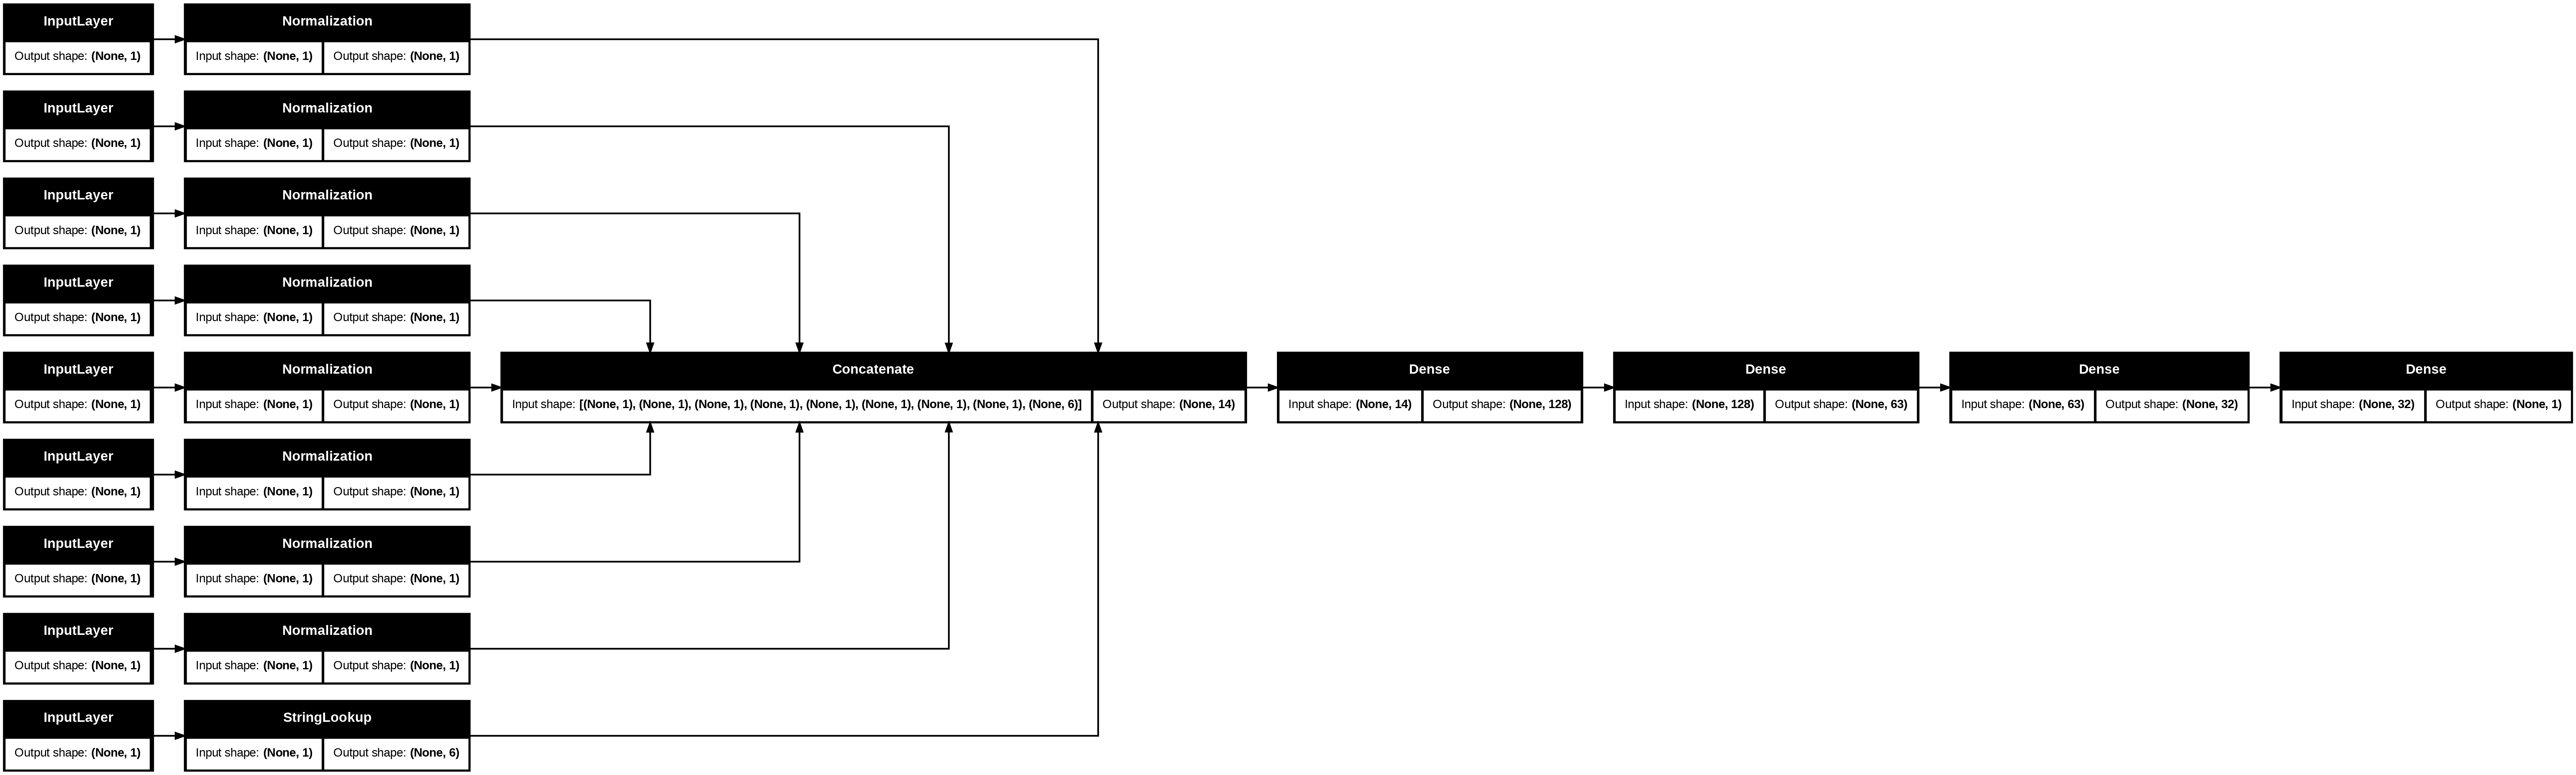

In [35]:
tf.keras.utils.plot_model(model, show_shapes=True, rankdir='LR')

In [36]:
history = model.fit(train_ds,
                    validation_data = test_ds,
                    epochs=50)

Epoch 1/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 39793807360.0000 - mae: 161902.4219 - val_loss: 10160236544.0000 - val_mae: 73352.9297
Epoch 2/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 7417405952.0000 - mae: 61468.7891 - val_loss: 6075575296.0000 - val_mae: 54895.5547
Epoch 3/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5359924736.0000 - mae: 52151.5508 - val_loss: 5149022208.0000 - val_mae: 51496.2266
Epoch 4/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4837329920.0000 - mae: 50056.0000 - val_loss: 4874950144.0000 - val_mae: 49898.8008
Epoch 5/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4658905600.0000 - mae: 49093.6367 - val_loss: 4780584960.0000 - val_mae: 50102.0273
Epoch 6/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 4566702080.0000 - mae: 48622.4609 - val_loss: 4708945920.0000 - val_mae: 48950.4453
Epoch 7/50
516/516 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 4511292416.0000 - mae: 48244.8906 - val_loss: 4669267456.0000 - val_mae:

# Deep Learning (PyTortch)

In [40]:
import torch
from torch.utils.data import TensorDataset, DataLoader

In [41]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [42]:
X_train_tensor = torch.tensor(X_train_processed, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_processed, dtype=torch.float32)

In [43]:
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [44]:
train_ds = TensorDataset(X_train_tensor, y_train_tensor)
test_ds = TensorDataset(X_test_tensor, y_test_tensor)

In [45]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

In [46]:
features, labels = next(iter(train_loader))
print(f"Features batch shape: {features.shape}")
print(f"Labels batch shape: {labels.shape}")

Features batch shape: torch.Size([32, 13])
Labels batch shape: torch.Size([32, 1])


In [47]:
import torch.nn as nn
import torch.nn.functional as F

class HousePriceNet(nn.Module):
  def __init__(self):
    super(HousePriceNet, self).__init__()

    self.fc1 = nn.Linear(13, 128)
    self.fc2 = nn.Linear(128, 64)
    self.fc3 = nn.Linear(64, 32)
    self.out = nn.Linear(32, 1)

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = F.relu(self.fc3(x))
    x = self.out(x)

    return x

In [48]:
pytorch_model = HousePriceNet()
print(pytorch_model)

HousePriceNet(
  (fc1): Linear(in_features=13, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (out): Linear(in_features=32, out_features=1, bias=True)
)


In [50]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(pytorch_model.parameters(), lr=0.001)

epochs = 50

for epoch in range(epochs):
  pytorch_model.train()

  running_loss = 0.0
  running_mae = 0.0

  for features, labels in train_loader:
    optimizer.zero_grad()

    predictions = pytorch_model(features)

    loss = criterion(predictions, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item() * features.size(0)

    mae = torch.abs(predictions - labels).mean()
    running_mae += mae.item() * features.size(0)

  if(epoch + 1) % 10 == 0:
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_mae = running_mae / len(train_loader.dataset)

    print(f"Epoch {epoch + 1}/{epochs} - Loss: {epoch_loss:.0f} - Train MAE: {epoch_mae:.0f}")

Epoch 10/50 - Loss: 4447993923 - Train MAE: 47676
Epoch 20/50 - Loss: 4269960239 - Train MAE: 46385
Epoch 30/50 - Loss: 4177434912 - Train MAE: 45543
Epoch 40/50 - Loss: 4118407153 - Train MAE: 45095
Epoch 50/50 - Loss: 4064656086 - Train MAE: 44718
